In [27]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt 
import numpy as np

In [4]:
#load audio files
debussy_file = "audio/debussy.wav"
redhot_file = "audio/redhot.wav"
duke_file = "audio/duke.wav"

In [5]:
debussy, _ = librosa.load(debussy_file)
duke, _ = librosa.load(duke_file)
redhot, _ = librosa.load(redhot_file)

In [51]:
# extract RMSE with librosa

FRAME_LENGTH = 1024
HOP_LENGTH = 512

rms_debussy = librosa.feature.rms(y=debussy, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
rms_redhot = librosa.feature.rms(y=redhot, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
rms_duke = librosa.feature.rms(y=duke, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

print(rms_debussy, rms_debussy.size)

[0.03491691 0.05298564 0.05961845 ... 0.01386144 0.01489561 0.01443748] 1292


In [10]:
rms_debussy.shape

(1292,)

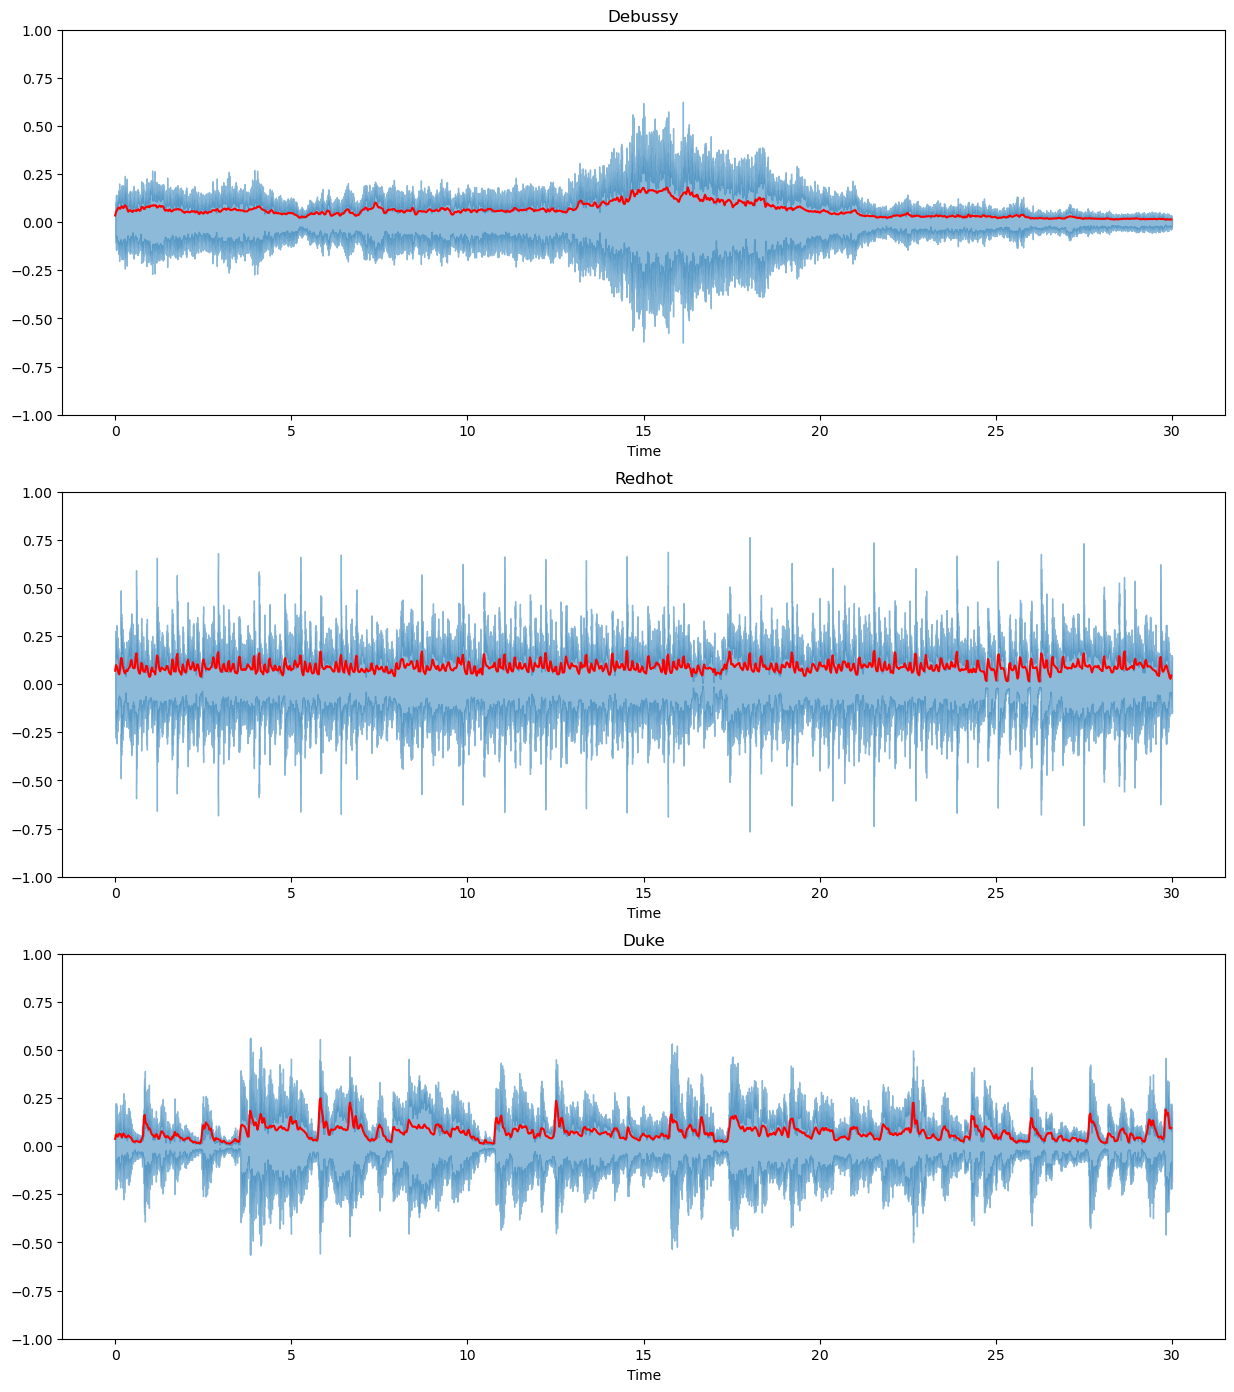

In [32]:

frames= range(len(rms_debussy))
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)

plt.figure(figsize=(15, 17))

plt.subplot(3, 1, 1)
librosa.display.waveshow(debussy, alpha=0.5)
plt.plot(t, rms_debussy, color="r")
plt.title("Debussy")
plt.ylim((-1, 1))

plt.subplot(3, 1, 2)
librosa.display.waveshow(redhot, alpha=0.5)
plt.plot(t, rms_redhot, color="r")
plt.title("Redhot")
plt.ylim((-1, 1))

plt.subplot(3, 1, 3)
librosa.display.waveshow(duke, alpha=0.5)
plt.plot(t, rms_duke, color="r")
plt.title("Duke")
plt.ylim((-1, 1))

plt.show()

In [59]:
# RMSE from scratch
def rmse(signal, frame_size, hop_length):
    rmse = []
    
    # calculate rmse for each frame
    for i in range(0, len(signal), hop_length): 
        rmse_current_frame = np.sqrt(sum(signal[i:i+frame_size]**2) / frame_size)
        rmse.append(rmse_current_frame)
    return np.array(rmse)  

In [60]:
rms1_debussy = rmse(debussy, frame_size=FRAME_LENGTH, hop_length=HOP_LENGTH)
rms1_redhot = rmse(redhot, frame_size=FRAME_LENGTH, hop_length=HOP_LENGTH)
rms1_duke = rmse(duke, frame_size=FRAME_LENGTH, hop_length=HOP_LENGTH)
print(rms1_debussy, rms1_debussy.size)

[0.05298564 0.05961845 0.06720149 ... 0.01489561 0.01443748 0.0089008 ] 1292


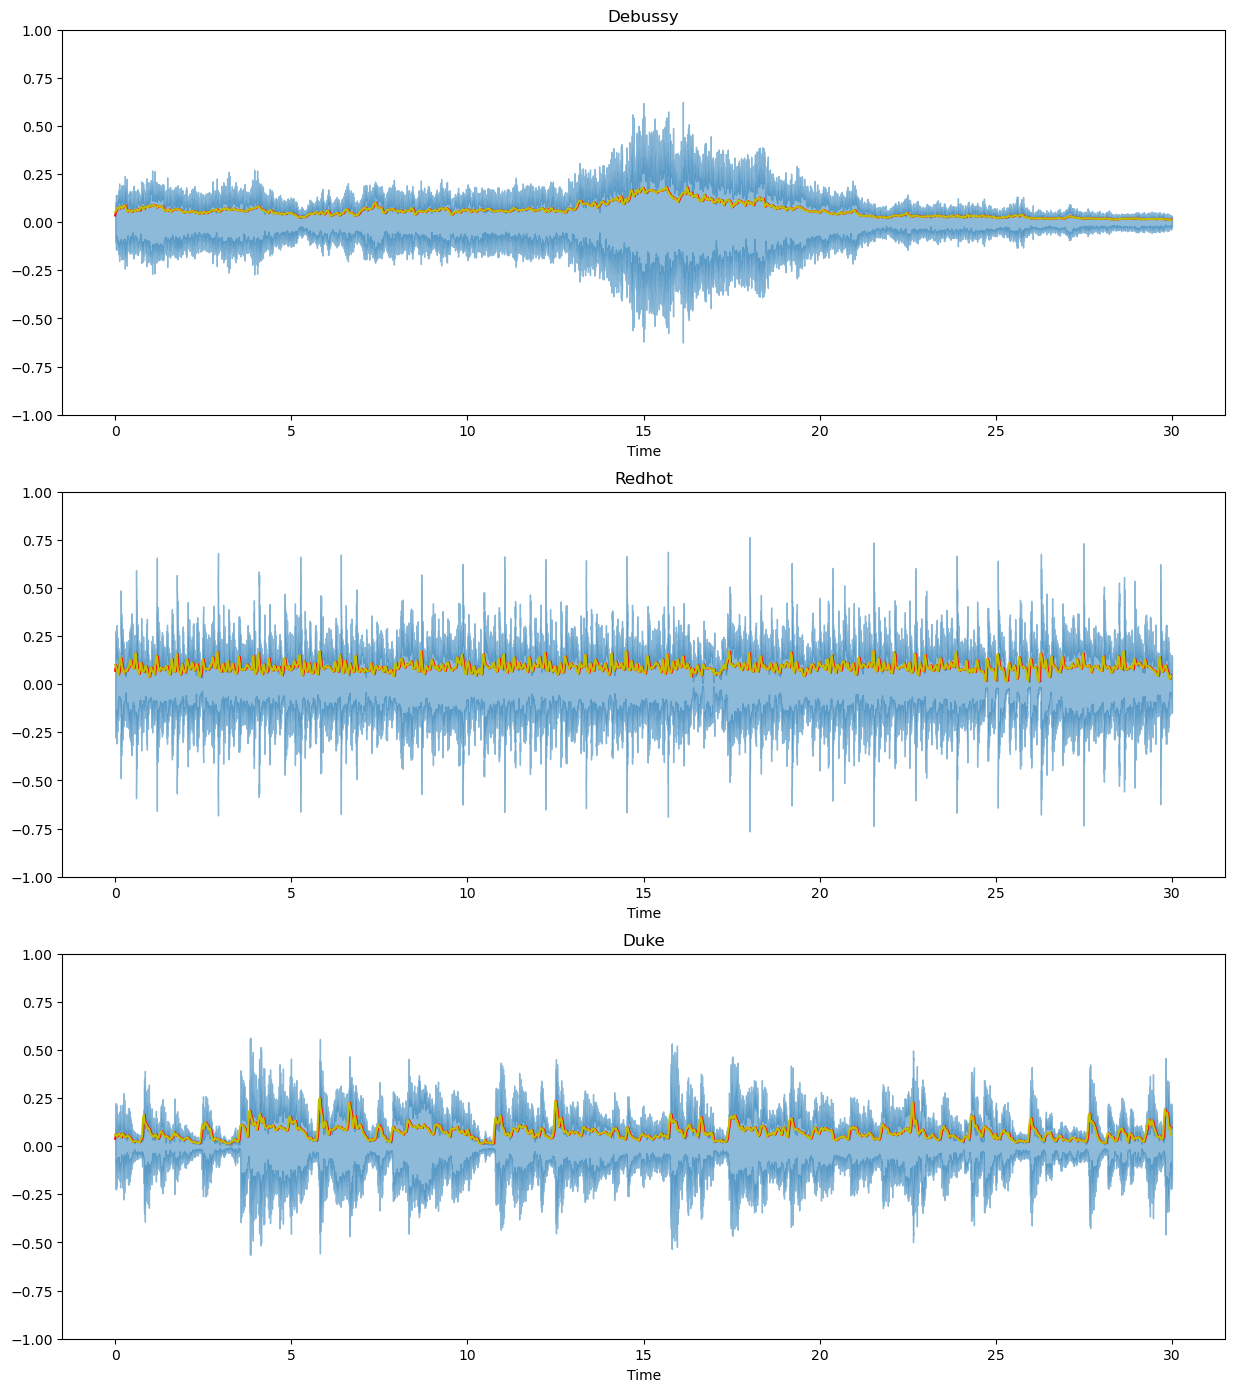

In [61]:
plt.figure(figsize=(15, 17))

plt.subplot(3, 1, 1)
librosa.display.waveshow(debussy, alpha=0.5)
plt.plot(t, rms_debussy, color="r")
plt.plot(t, rms1_debussy, color="y")
plt.title("Debussy")
plt.ylim((-1, 1))

plt.subplot(3, 1, 2)
librosa.display.waveshow(redhot, alpha=0.5)
plt.plot(t, rms_redhot, color="r")
plt.plot(t, rms1_redhot, color="y")
plt.title("Redhot")
plt.ylim((-1, 1))

plt.subplot(3, 1, 3)
librosa.display.waveshow(duke, alpha=0.5)
plt.plot(t, rms_duke, color="r")
plt.plot(t, rms1_duke, color="y")
plt.title("Duke")
plt.ylim((-1, 1))

plt.show()

In [62]:
# zero crossing rate
zcr_debussy = librosa.feature.zero_crossing_rate(y=debussy, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
zcr_redhot = librosa.feature.zero_crossing_rate(y=redhot, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
zcr_duke = librosa.feature.zero_crossing_rate(y=duke, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

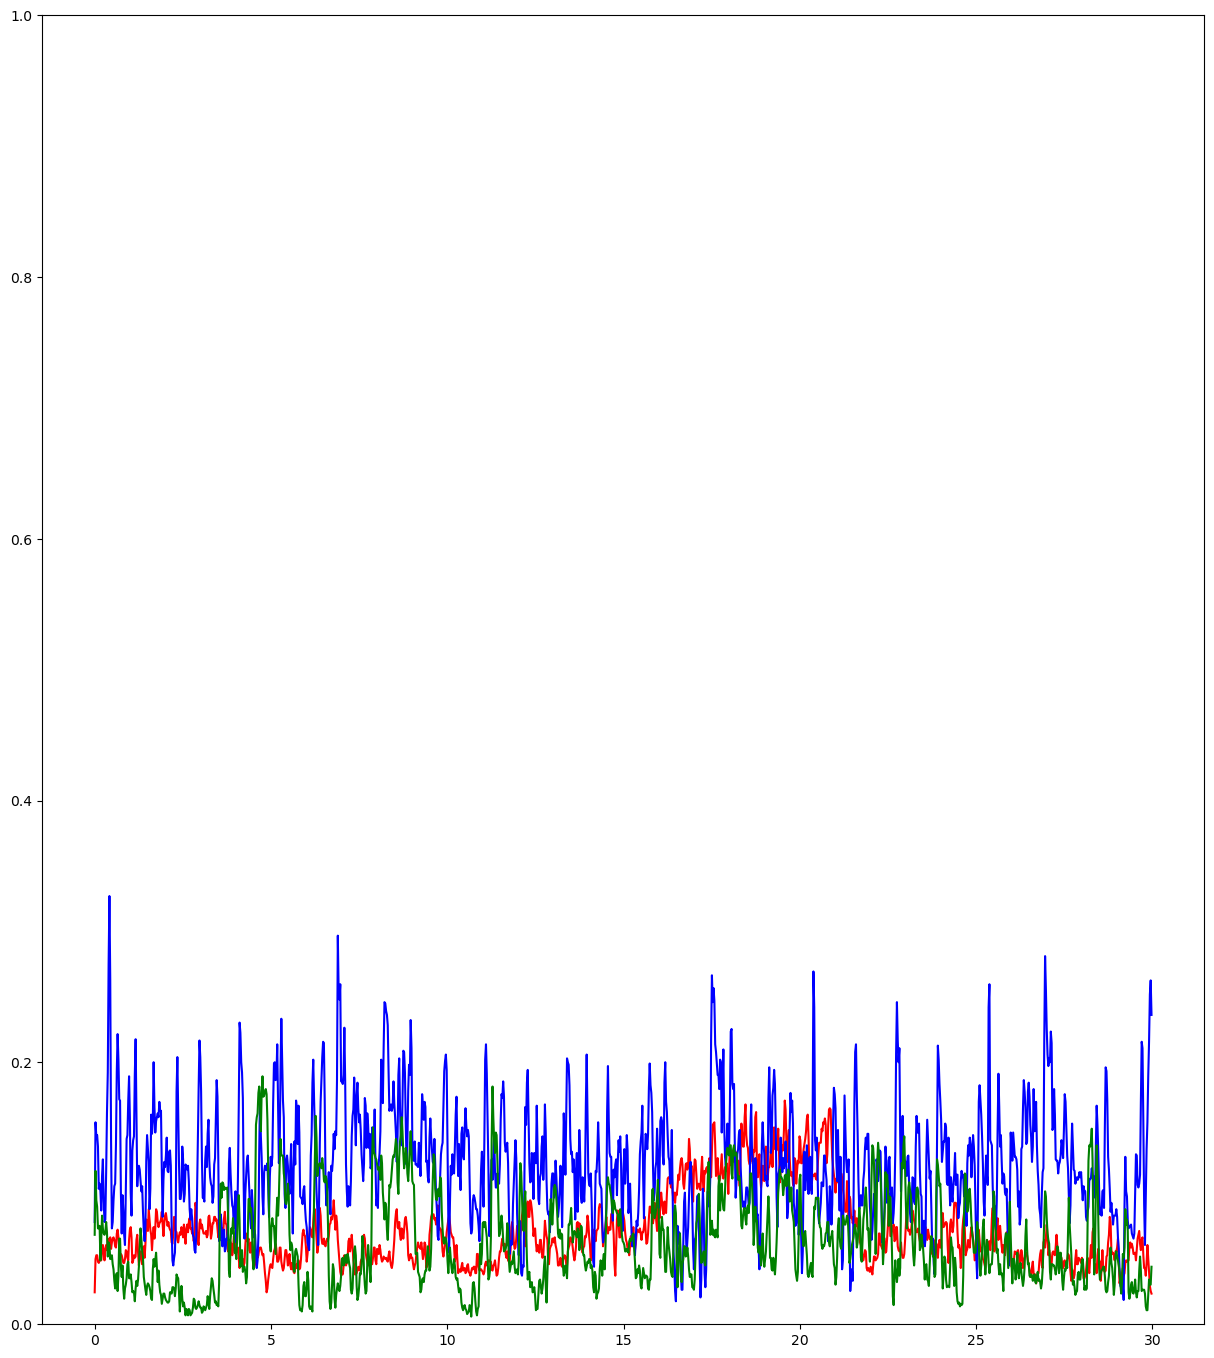

In [64]:
# visualize zcr
plt.figure(figsize=(15, 17))
plt.plot(t, zcr_debussy, color="r")
plt.plot(t, zcr_redhot, color="b")
plt.plot(t, zcr_duke, color="g")
plt.ylim((0, 1))

plt.show()